In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import nltk
import re
import string
import numpy as np

In [2]:
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

In [3]:
df = pd.read_csv("Keyword_logistik_pemilu_2024.csv")

In [4]:
df_mulai = df

In [5]:
Berita = df_mulai['konten']

# cleaning data

In [6]:
def clean_text(text):
    # menghapus user name twiter
    text=re.sub('@[^\s]+',' ',text)
    # menghapus https dan http
    text=re.sub(r"(?:\@|http?\://|https?\://|www)\s+","", text)
    #remove URL
    text=re.sub(r'\w+:\/{2}[\d\w-]+(\.[\d\w-]+)*(?:(?:\/[^\s/]*))*',"", text)
    # menghilangkan tanda baca 
    text = text.translate(str.maketrans(' ',' ',string.punctuation))
    # menghilangkan karakter html dengan tanda petik
    text=re.sub('<*?>',' ', text)
    #mempertimbangkan huruf dan angka
    text = re.sub('[^a-zA-Z]',' ',text)
    # mengganti nine baru dengan sepasi
    text = re.sub("\n", ' ',text)
    #mengubah ke huruf kecil
    text = text.lower()
    # menghapus single char
    text = re.sub(r"\b[a-zA-Z]\b",' ',text)
    # memisalkan dan mengabungkan kata
    text=' '.join(text.split())
    return text

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Asus\AppData\Local\Temp\ipykernel_14696\1932852581.py:3: SyntaxWarning: invalid escape sequence '\s'
  text=re.sub('@[^\s]+',' ',text)


In [7]:
df_mulai['clean'] = [clean_text(i) for i in Berita]
Berita = df_mulai['clean']

In [8]:
df_mulai.head(50)

,url,judul,konten,sumber,tanggal,clean
0,https://pasuruankab.go.id/berita/bawaslu-kabup...,Bawaslu Kabupaten Pasuruan Tak Temukan Pelangg...,"""Karena distribusi logistik Pemilu 2024 sudah ...",Pemerintah Kabupaten Pasuruan,1 week ago,karena distribusi logistik pemilu sudah diteri...
1,https://radarmadura.jawapos.com/sumenep/746957...,"Kejari Sumenep Belum Tetapkan Tersangka, Terka...","SUMENEP, RadarMadura.id Ð Kejaksaan Negeri (Ke...",Radar Madura,6 hours ago,sumenep radarmaduraid kejaksaan negeri kejari ...
2,https://rri.co.id/daerah/2030157/sisa-logistik...,Sisa Logistik Pemilu 2024 Dimusnahkan KPU Maros,"KBRN, Maros : Komisi Pemilihan Umum (KPU) Kabu...",RRI.co.id,6 days ago,kbrn maros komisi pemilihan umum kpu kabupaten...
3,https://www.posindonesia.co.id/id/articles/det...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Pos Indonesia,10-Feb-25,dukung kelancaran distribusi logistik pemilu k...
4,https://alkhairaat.com/rapat-koordinasi-nasion...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,alkhairaat.com,17-Oct-25,rapat koordinasi nasional kpu sulteng raih cap...
5,https://pekaaksara.com/14227/dugaan-kasus-koru...,Dugaan Kasus Korupsi Logistik Pemilu 2024 Masu...,Dugaan Kasus Korupsi Logistik Pemilu 2024 Masu...,Peka Aksara,22-Aug-25,dugaan kasus korupsi logistik pemilu masuk tah...
6,https://tribratanews.papua.polri.go.id/kapolre...,Kapolres Boven Digoel Hadiri Pemberangkatan Lo...,"Boven Digoel, -Kapolres Boven Digoel AKBP Wisn...",TBNews Polda Papua,1-Aug-25,boven digoel kapolres boven digoel akbp wisnu ...
7,https://www.tintahijau.com/ragam/kpu-subang-le...,KPU Subang Lelang Surat Suara dan Logistik Pem...,KPU Subang Lelang Surat Suara dan Logistik Pem...,TINTAHIJAU.com,12-Sep-25,kpu subang lelang surat suara dan logistik pem...
8,https://suaraindonesia.co.id/news/news/68a7e40...,"Dugaan Penyimpangan Logistik Pemilu 2024, Kant...","Dugaan Penyimpangan Logistik Pemilu 2024, Kant...",suara indonesia,22-Aug-25,dugaan penyimpangan logistik pemilu kantor kpu...
9,https://www.antaranews.com/berita/4855997/kpu-...,KPU: Penggunaan jet pribadi hanya untuk antar ...,Ketua Komisi Pemilihan Umum (KPU) Mochammad AÞ...,ANTARA News,24-May-25,ketua komisi pemilihan umum kpu mochammad fudd...


# remove duplicate

In [9]:
# remove the duplicate tweet
df_mulai=df_mulai[~df_mulai['clean'].duplicated()]
df_mulai=df_mulai.reset_index(drop=True)
df_mulai.head()

,url,judul,konten,sumber,tanggal,clean
0,https://pasuruankab.go.id/berita/bawaslu-kabup...,Bawaslu Kabupaten Pasuruan Tak Temukan Pelangg...,"""Karena distribusi logistik Pemilu 2024 sudah ...",Pemerintah Kabupaten Pasuruan,1 week ago,karena distribusi logistik pemilu sudah diteri...
1,https://radarmadura.jawapos.com/sumenep/746957...,"Kejari Sumenep Belum Tetapkan Tersangka, Terka...","SUMENEP, RadarMadura.id Ð Kejaksaan Negeri (Ke...",Radar Madura,6 hours ago,sumenep radarmaduraid kejaksaan negeri kejari ...
2,https://rri.co.id/daerah/2030157/sisa-logistik...,Sisa Logistik Pemilu 2024 Dimusnahkan KPU Maros,"KBRN, Maros : Komisi Pemilihan Umum (KPU) Kabu...",RRI.co.id,6 days ago,kbrn maros komisi pemilihan umum kpu kabupaten...
3,https://www.posindonesia.co.id/id/articles/det...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Pos Indonesia,10-Feb-25,dukung kelancaran distribusi logistik pemilu k...
4,https://alkhairaat.com/rapat-koordinasi-nasion...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,alkhairaat.com,17-Oct-25,rapat koordinasi nasional kpu sulteng raih cap...


# TOKENIZING

In [10]:
from nltk.tokenize import RegexpTokenizer
regexp = RegexpTokenizer(r'\w+|$[0-9]+|\s+')
df_mulai['Token'] = df_mulai['clean'].apply(regexp.tokenize)
df_mulai

,url,judul,konten,sumber,tanggal,clean,Token
0,https://pasuruankab.go.id/berita/bawaslu-kabup...,Bawaslu Kabupaten Pasuruan Tak Temukan Pelangg...,"""Karena distribusi logistik Pemilu 2024 sudah ...",Pemerintah Kabupaten Pasuruan,1 week ago,karena distribusi logistik pemilu sudah diteri...,"[karena, , distribusi, , logistik, , pemilu..."
1,https://radarmadura.jawapos.com/sumenep/746957...,"Kejari Sumenep Belum Tetapkan Tersangka, Terka...","SUMENEP, RadarMadura.id Ð Kejaksaan Negeri (Ke...",Radar Madura,6 hours ago,sumenep radarmaduraid kejaksaan negeri kejari ...,"[sumenep, , radarmaduraid, , kejaksaan, , n..."
2,https://rri.co.id/daerah/2030157/sisa-logistik...,Sisa Logistik Pemilu 2024 Dimusnahkan KPU Maros,"KBRN, Maros : Komisi Pemilihan Umum (KPU) Kabu...",RRI.co.id,6 days ago,kbrn maros komisi pemilihan umum kpu kabupaten...,"[kbrn, , maros, , komisi, , pemilihan, , u..."
3,https://www.posindonesia.co.id/id/articles/det...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Pos Indonesia,10-Feb-25,dukung kelancaran distribusi logistik pemilu k...,"[dukung, , kelancaran, , distribusi, , logi..."
4,https://alkhairaat.com/rapat-koordinasi-nasion...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,alkhairaat.com,17-Oct-25,rapat koordinasi nasional kpu sulteng raih cap...,"[rapat, , koordinasi, , nasional, , kpu, ,..."
...,...,...,...,...,...,...,...
189,https://suarajatimpost.com/kejari-sumenep-dala...,Kejari Sumenep Dalami Korupsi Logistik Pemilu ...,Kejari Sumenep mendalami kasus korupsi logisti...,Suara Jatim Post,18-Sep-25,kejari sumenep mendalami kasus korupsi logisti...,"[kejari, , sumenep, , mendalami, , kasus, ..."
190,https://www.beritasatu.com/jatim/2923405/kejar...,Kejari Sumenep Dalami Korupsi Logistik Pemilu ...,"Kejaksaan Negeri (Kejari) Sumenep, Jawa Timur,...",BeritaSatu.com,18-Sep-25,kejaksaan negeri kejari sumenep jawa timur ter...,"[kejaksaan, , negeri, , kejari, , sumenep, ..."
191,https://news.detik.com/berita/d-8172610/dkpp-a...,DKPP: Anggaran Sewa Private Jet KPU Rp 90 M da...,Dewan Kehormatan Penyelenggara Pemilu menjatuh...,detikNews,1 month ago,dewan kehormatan penyelenggara pemilu menjatuh...,"[dewan, , kehormatan, , penyelenggara, , pe..."
192,https://www.tempo.co/hukum/polemik-jet-pribadi...,"Polemik Jet Pribadi KPU, Hasyim Asy'ari: Untuk...",Penyewaan jet pribadi oleh KPU di tengah tahap...,Tempo.co,17-May-25,penyewaan jet pribadi oleh kpu di tengah tahap...,"[penyewaan, , jet, , pribadi, , oleh, , kp..."


# NORMALISASI

In [13]:
normalized_word = pd.read_csv("Normalisasi.csv")

normalized_word_dict={}
for index, row in normalized_word.iterrows():
    if row[0] not in normalized_word_dict:
        normalized_word_dict[row[0]] = row[1]
    
def normalozed_term(document):
    return [normalized_word_dict[term] if term in normalized_word_dict else term for term in document]

df_mulai["Normalisasi"] = df_mulai['Token'].apply(normalozed_term)
df_mulai.head(50)

C:\Users\Asus\AppData\Local\Temp\ipykernel_14696\179275958.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[0] not in normalized_word_dict:
C:\Users\Asus\AppData\Local\Temp\ipykernel_14696\179275958.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normalized_word_dict[row[0]] = row[1]


,url,judul,konten,sumber,tanggal,clean,Token,Normalisasi,stopwords
0,https://pasuruankab.go.id/berita/bawaslu-kabup...,Bawaslu Kabupaten Pasuruan Tak Temukan Pelangg...,"""Karena distribusi logistik Pemilu 2024 sudah ...",Pemerintah Kabupaten Pasuruan,1 week ago,karena distribusi logistik pemilu sudah diteri...,"[karena, , distribusi, , logistik, , pemilu...","[karena, , distribusi, , logistik, , pemilu...","[ , distribusi, , logistik, , pemilu, , , ..."
1,https://radarmadura.jawapos.com/sumenep/746957...,"Kejari Sumenep Belum Tetapkan Tersangka, Terka...","SUMENEP, RadarMadura.id Ð Kejaksaan Negeri (Ke...",Radar Madura,6 hours ago,sumenep radarmaduraid kejaksaan negeri kejari ...,"[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , kejaksaan, , n..."
2,https://rri.co.id/daerah/2030157/sisa-logistik...,Sisa Logistik Pemilu 2024 Dimusnahkan KPU Maros,"KBRN, Maros : Komisi Pemilihan Umum (KPU) Kabu...",RRI.co.id,6 days ago,kbrn maros komisi pemilihan umum kpu kabupaten...,"[kbrn, , maros, , komisi, , pemilihan, , u...","[kbrn, , maros, , komisi, , pemilihan, , u...","[kbrn, , maros, , komisi, , pemilihan, , ..."
3,https://www.posindonesia.co.id/id/articles/det...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Pos Indonesia,10-Feb-25,dukung kelancaran distribusi logistik pemilu k...,"[dukung, , kelancaran, , distribusi, , logi...","[dukung, , kelancaran, , distribusi, , logi...","[dukung, , kelancaran, , distribusi, , logi..."
4,https://alkhairaat.com/rapat-koordinasi-nasion...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,alkhairaat.com,17-Oct-25,rapat koordinasi nasional kpu sulteng raih cap...,"[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, ,..."
5,https://pekaaksara.com/14227/dugaan-kasus-koru...,Dugaan Kasus Korupsi Logistik Pemilu 2024 Masu...,Dugaan Kasus Korupsi Logistik Pemilu 2024 Masu...,Peka Aksara,22-Aug-25,dugaan kasus korupsi logistik pemilu masuk tah...,"[dugaan, , kasus, , korupsi, , logistik, ,...","[dugaan, , kasus, , korupsi, , logistik, ,...","[dugaan, , , korupsi, , logistik, , pemilu..."
6,https://tribratanews.papua.polri.go.id/kapolre...,Kapolres Boven Digoel Hadiri Pemberangkatan Lo...,"Boven Digoel, -Kapolres Boven Digoel AKBP Wisn...",TBNews Polda Papua,1-Aug-25,boven digoel kapolres boven digoel akbp wisnu ...,"[boven, , digoel, , kapolres, , boven, , d...","[boven, , digoel, , kapolres, , boven, , d...","[boven, , digoel, , kapolres, , boven, , d..."
7,https://www.tintahijau.com/ragam/kpu-subang-le...,KPU Subang Lelang Surat Suara dan Logistik Pem...,KPU Subang Lelang Surat Suara dan Logistik Pem...,TINTAHIJAU.com,12-Sep-25,kpu subang lelang surat suara dan logistik pem...,"[kpu, , subang, , lelang, , surat, , suara...","[kpu, , subang, , lelang, , surat, , suara...","[kpu, , subang, , lelang, , surat, , suara..."
8,https://suaraindonesia.co.id/news/news/68a7e40...,"Dugaan Penyimpangan Logistik Pemilu 2024, Kant...","Dugaan Penyimpangan Logistik Pemilu 2024, Kant...",suara indonesia,22-Aug-25,dugaan penyimpangan logistik pemilu kantor kpu...,"[dugaan, , penyimpangan, , logistik, , pemi...","[dugaan, , penyimpangan, , logistik, , pemi...","[dugaan, , penyimpangan, , logistik, , pemi..."
9,https://www.antaranews.com/berita/4855997/kpu-...,KPU: Penggunaan jet pribadi hanya untuk antar ...,Ketua Komisi Pemilihan Umum (KPU) Mochammad AÞ...,ANTARA News,24-May-25,ketua komisi pemilihan umum kpu mochammad fudd...,"[ketua, , komisi, , pemilihan, , umum, , k...","[ketua, , komisi, , pemilihan, , umum, , k...","[ketua, , komisi, , pemilihan, , , kpu, ,..."


# remove stopwoeds

In [14]:
from nltk.corpus import stopwords
stopword = stopwords.words('indonesian')
txt_stopword = pd.read_csv("stopwords.txt", names= ["stopwords"], header = None)

stopword.extend(["ckck", "naaaaa", "ahy", "PN", "yg", "dg", "rt", "ttap", "YK", "KY", "dgn", "ny", "d", "klo", "kalo", "amp", "biar", "bikin", "bilang", "gak", "ga", "krn", "nya", "nih", "sih", "si", "si", "tau", "tdk", "tuh", "utk", "ya", "jd", "jgn", "sdh", "aja", "n", "t", "nya", "hehe", "pen", "u", "loh", "rt", "&amp", "yah", "brojikalau", "jk", "wan", "kek", "eh", "mk", "klw", "kyknya", "wk", "wkwkwkwkwkwk", "gua", "ii", "ri", "hi", "on", "abah", "of", "yt", "aj", "oon", "jdwl", "hsl", "cm", "lu", "by", "emg", "kp", "wwkw", "wkwk", "mlh", "kl", "dw"])

stopword.extend(txt_stopword["stopwords"][0].split(' '))
stopword = set(stopword)

def stopwords(text):
    text = [word for word in text if word not in stopword]
    return text
df_mulai['stopwords'] = df_mulai["Normalisasi"].apply(stopwords)
df_mulai.head(50)

,url,judul,konten,sumber,tanggal,clean,Token,Normalisasi,stopwords
0,https://pasuruankab.go.id/berita/bawaslu-kabup...,Bawaslu Kabupaten Pasuruan Tak Temukan Pelangg...,"""Karena distribusi logistik Pemilu 2024 sudah ...",Pemerintah Kabupaten Pasuruan,1 week ago,karena distribusi logistik pemilu sudah diteri...,"[karena, , distribusi, , logistik, , pemilu...","[karena, , distribusi, , logistik, , pemilu...","[ , distribusi, , logistik, , pemilu, , , ..."
1,https://radarmadura.jawapos.com/sumenep/746957...,"Kejari Sumenep Belum Tetapkan Tersangka, Terka...","SUMENEP, RadarMadura.id Ð Kejaksaan Negeri (Ke...",Radar Madura,6 hours ago,sumenep radarmaduraid kejaksaan negeri kejari ...,"[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , kejaksaan, , n..."
2,https://rri.co.id/daerah/2030157/sisa-logistik...,Sisa Logistik Pemilu 2024 Dimusnahkan KPU Maros,"KBRN, Maros : Komisi Pemilihan Umum (KPU) Kabu...",RRI.co.id,6 days ago,kbrn maros komisi pemilihan umum kpu kabupaten...,"[kbrn, , maros, , komisi, , pemilihan, , u...","[kbrn, , maros, , komisi, , pemilihan, , u...","[kbrn, , maros, , komisi, , pemilihan, , ..."
3,https://www.posindonesia.co.id/id/articles/det...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Pos Indonesia,10-Feb-25,dukung kelancaran distribusi logistik pemilu k...,"[dukung, , kelancaran, , distribusi, , logi...","[dukung, , kelancaran, , distribusi, , logi...","[dukung, , kelancaran, , distribusi, , logi..."
4,https://alkhairaat.com/rapat-koordinasi-nasion...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,alkhairaat.com,17-Oct-25,rapat koordinasi nasional kpu sulteng raih cap...,"[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, ,..."
5,https://pekaaksara.com/14227/dugaan-kasus-koru...,Dugaan Kasus Korupsi Logistik Pemilu 2024 Masu...,Dugaan Kasus Korupsi Logistik Pemilu 2024 Masu...,Peka Aksara,22-Aug-25,dugaan kasus korupsi logistik pemilu masuk tah...,"[dugaan, , kasus, , korupsi, , logistik, ,...","[dugaan, , kasus, , korupsi, , logistik, ,...","[dugaan, , , korupsi, , logistik, , pemilu..."
6,https://tribratanews.papua.polri.go.id/kapolre...,Kapolres Boven Digoel Hadiri Pemberangkatan Lo...,"Boven Digoel, -Kapolres Boven Digoel AKBP Wisn...",TBNews Polda Papua,1-Aug-25,boven digoel kapolres boven digoel akbp wisnu ...,"[boven, , digoel, , kapolres, , boven, , d...","[boven, , digoel, , kapolres, , boven, , d...","[boven, , digoel, , kapolres, , boven, , d..."
7,https://www.tintahijau.com/ragam/kpu-subang-le...,KPU Subang Lelang Surat Suara dan Logistik Pem...,KPU Subang Lelang Surat Suara dan Logistik Pem...,TINTAHIJAU.com,12-Sep-25,kpu subang lelang surat suara dan logistik pem...,"[kpu, , subang, , lelang, , surat, , suara...","[kpu, , subang, , lelang, , surat, , suara...","[kpu, , subang, , lelang, , surat, , suara..."
8,https://suaraindonesia.co.id/news/news/68a7e40...,"Dugaan Penyimpangan Logistik Pemilu 2024, Kant...","Dugaan Penyimpangan Logistik Pemilu 2024, Kant...",suara indonesia,22-Aug-25,dugaan penyimpangan logistik pemilu kantor kpu...,"[dugaan, , penyimpangan, , logistik, , pemi...","[dugaan, , penyimpangan, , logistik, , pemi...","[dugaan, , penyimpangan, , logistik, , pemi..."
9,https://www.antaranews.com/berita/4855997/kpu-...,KPU: Penggunaan jet pribadi hanya untuk antar ...,Ketua Komisi Pemilihan Umum (KPU) Mochammad AÞ...,ANTARA News,24-May-25,ketua komisi pemilihan umum kpu mochammad fudd...,"[ketua, , komisi, , pemilihan, , umum, , k...","[ketua, , komisi, , pemilihan, , umum, , k...","[ketua, , komisi, , pemilihan, , , kpu, ,..."


In [15]:
tweet = pd.DataFrame(df_mulai)
tweet.to_csv ('clean.csv', index = False, header=True)

# STEMMING

In [16]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import swifter

factory = StemmerFactory()
Stemmer = factory.create_stemmer()


def stemmed_wrapper(term):
    if term.lower() == "pemilu":
        return term
    return Stemmer.stem(term)

term_dict = {}


tweet = df_mulai['stopwords']
for doc in tweet:
    for term in doc:
        if term not in term_dict:
            term_dict[term] = ' '
    print(len(term_dict))
    print("------------------------")

for term in term_dict:
    term_dict[term] = stemmed_wrapper(term)
    print(term, ":", term_dict[term])
    print(len(term_dict))
    print("------------------------")


C:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


11
------------------------
22
------------------------
32
------------------------
40
------------------------
53
------------------------
67
------------------------
81
------------------------
91
------------------------
96
------------------------
102
------------------------
112
------------------------
123
------------------------
133
------------------------
141
------------------------
147
------------------------
161
------------------------
167
------------------------
176
------------------------
183
------------------------
192
------------------------
197
------------------------
208
------------------------
213
------------------------
215
------------------------
221
------------------------
228
------------------------
237
------------------------
248
------------------------
256
------------------------
260
------------------------
266
------------------------
275
------------------------
279
------------------------
282
------------------------
293
-------------------

nampak : nampak
11790
------------------------
terang : terang
11790
------------------------
benderang : benderang
11790
------------------------
nepotisme : nepotisme
11790
------------------------
habis : habis
11790
------------------------
percaya : percaya
11790
------------------------
wasit : wasit
11790
------------------------
penyelenggara : selenggara
11790
------------------------
pemilu : pemilu
11790
------------------------
perhitungan : hitung
11790
------------------------
abud : abud
11790
------------------------
kavling : kavling
11790
------------------------
surga : surga
11790
------------------------
sakjose : sakjose
11790
------------------------
buta : buta
11790
------------------------
data : data
11790
------------------------
real : real
11790
------------------------
independen : independen
11790
------------------------
kawal : kawal
11790
------------------------
caci : caci
11790
------------------------
maki : maki
11790
------------------------
ter

menghentikan : henti
11790
------------------------
buruk : buruk
11790
------------------------
berkuasa : kuasa
11790
------------------------
tolol : tolol
11790
------------------------
casing : casing
11790
------------------------
blankogolput : blankogolput
11790
------------------------
terhormat : hormat
11790
------------------------
kpkpkpk : kpkpkpk
11790
------------------------
lihat : lihat
11790
------------------------
kpk : kpk
11790
------------------------
setujungk : setujungk
11790
------------------------
kasusin : kasusin
11790
------------------------
nadim : nadim
11790
------------------------
tim : tim
11790
------------------------
bentuk : bentuk
11790
------------------------
kecurangannya : curang
11790
------------------------
manipulasi : manipulasi
11790
------------------------
pengkondisian : kondisi
11790
------------------------
pra : pra
11790
------------------------
sumber : sumber
11790
------------------------
daya : daya
11790
--------------

kalal : kalal
11790
------------------------
kegiatan : giat
11790
------------------------
butuh : butuh
11790
------------------------
lembaga : lembaga
11790
------------------------
survey : survey
11790
------------------------
membuka : buka
11790
------------------------
mendanai : dana
11790
------------------------
kpninu : kpninu
11790
------------------------
mandiri : mandiri
11790
------------------------
publik : publik
11790
------------------------
ujung : ujung
11790
------------------------
web : web
11790
------------------------
dibuka : buka
11790
------------------------
konflik : konflik
11790
------------------------
pemerintah : perintah
11790
------------------------
nunjukin : nunjukin
11790
------------------------
pilih : pilih
11790
------------------------
wkwkwkwkwkwkw : wkwkwkwkwkwkw
11790
------------------------
salut : salut
11790
------------------------
bennyidialisme : bennyidialisme
11790
------------------------
kuatsebagai : kuatsebagai
11790
-

...

hbis : hbis
11790
------------------------
amggota : amggota
11790
------------------------
disyaratkan : syarat
11790
------------------------
mencerdaskan : cerdas
11790
------------------------
pusatnya : pusat
11790
------------------------
tumben : tumben
11790
------------------------
menyri : menyri
11790
------------------------
perioda : perioda
11790
------------------------
didlm : didlm
11790
------------------------
pemerrintahan : pemerrintahan
11790
------------------------
sjk : sjk
11790
------------------------
soy : soy
11790
------------------------
pantang : pantang
11790
------------------------
penerintahan : penerintahan
11790
------------------------
dicalonkan : calon
11790
------------------------
nyepimasa : nyepimasa
11790
------------------------
jalancari : jalancari
11790
------------------------
diridhoi : diridhoi
11790
------------------------
pemilihpendukungnya : pemilihpendukungnya
11790
------------------------
ntr : ntr
11790
--------------------

memperjuangun : memperjuangun
11790
------------------------
harepin : harepin
11790
------------------------
bary : bary
11790
------------------------
melengkapi : lengkap
11790
------------------------
kehutanan : hutan
11790
------------------------
digabungkan : gabung
11790
------------------------
pisahkahkan : pisahkahkan
11790
------------------------
tumpang : tumpang
11790
------------------------
tindih : tindih
11790
------------------------
keberadaan : ada
11790
------------------------
aleg : aleg
11790
------------------------
pragmatis : pragmatis
11790
------------------------
gassssss : gassssss
11790
------------------------
tips : tips
11790
------------------------
copot : copot
11790
------------------------
cendekiawan : cendekiawan
11790
------------------------
aktipes : aktipes
11790
------------------------
ppln : ppln
11790
------------------------
newssatu : newssatu
11790
------------------------
pelanggaranpemilu : pelanggaranpemilu
11790
--------------

parlemenperempuan : parlemenperempuan
11790
------------------------
puanmaharani : puanmaharani
11790
------------------------
wkkwk : wkkwk
11790
------------------------
akademisnya : akademis
11790
------------------------
ditekankan : tekan
11790
------------------------
urusannyahubungannya : urusannyahubungannya
11790
------------------------
diendoresement : diendoresement
11790
------------------------
tubirin : tubirin
11790
------------------------
diadain : diadain
11790
------------------------
berbohong : bohong
11790
------------------------
mengeliminasi : eliminasi
11790
------------------------
ajur : ajur
11790
------------------------
honestly : honestly
11790
------------------------
love : love
11790
------------------------
series : series
11790
------------------------
ibadahmu : ibadah
11790
------------------------
asikk : asikk
11790
------------------------
jin : jin
11790
------------------------
dijelasin : dijelasin
11790
------------------------
orator :

kecurangansdh : kecurangansdh
11790
------------------------
instansi : instansi
11790
------------------------
netralicw : netralicw
11790
------------------------
ibnu : ibnu
11790
------------------------
hajar : hajar
11790
------------------------
lsi : lsi
11790
------------------------
bacod : bacod
11790
------------------------
benua : benua
11790
------------------------
antartika : antartika
11790
------------------------
memberitahukan : memberitahukan
11790
------------------------
sudi : sudi
11790
------------------------
pelantikan : lantik
11790
------------------------
sekelik : kelik
11790
------------------------
subsatgas : subsatgas
11790
------------------------
ditsamapta : ditsamapta
11790
------------------------
krakatau : krakatau
11790
------------------------
ayojagapersatuandankesatuanbangsa : ayojagapersatuandankesatuanbangsa
11790
------------------------
cintakebhinekaan : cintakebhinekaan
11790
------------------------
ombkrakatau : ombkrakatau
11790


menjegal : jegal
11790
------------------------
kelanjutannya : lanjut
11790
------------------------
kitani : kitani
11790
------------------------
dibutuhin : dibutuhin
11790
------------------------
kasubag : kasubag
11790
------------------------
sidalih : sidalih
11790
------------------------
kpusumbabarat : kpusumbabarat
11790
------------------------
resor : resor
11790
------------------------
persaingan : saing
11790
------------------------
ngehina : ngehina
11790
------------------------
ngerendahin : ngerendahin
11790
------------------------
angketvsrakyat : angketvsrakyat
11790
------------------------
akrobatpolitik : akrobatpolitik
11790
------------------------
musuhkita : musuhkita
11790
------------------------
iyalahkomitmen : iyalahkomitmen
11790
------------------------
payahitu : payahitu
11790
------------------------
kamugak : kamugak
11790
------------------------
menangbelum : menangbelum
11790
------------------------
kalahikut : kalahikut
11790
-----------

In [17]:
def get_stemmed_term(doc):
    return [term_dict[term] for term in doc]

df_mulai['stemmer'] = df_mulai['stopwords'].apply(get_stemmed_term)
df_mulai.head(50)

,url,judul,konten,sumber,tanggal,clean,Token,Normalisasi,stopwords,stemmer
0,https://pasuruankab.go.id/berita/bawaslu-kabup...,Bawaslu Kabupaten Pasuruan Tak Temukan Pelangg...,"""Karena distribusi logistik Pemilu 2024 sudah ...",Pemerintah Kabupaten Pasuruan,1 week ago,karena distribusi logistik pemilu sudah diteri...,"[karena, , distribusi, , logistik, , pemilu...","[karena, , distribusi, , logistik, , pemilu...","[ , distribusi, , logistik, , pemilu, , , ...","[, distribusi, , logistik, , pemilu, , , terim..."
1,https://radarmadura.jawapos.com/sumenep/746957...,"Kejari Sumenep Belum Tetapkan Tersangka, Terka...","SUMENEP, RadarMadura.id Ð Kejaksaan Negeri (Ke...",Radar Madura,6 hours ago,sumenep radarmaduraid kejaksaan negeri kejari ...,"[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , jaksa, , negeri, ..."
2,https://rri.co.id/daerah/2030157/sisa-logistik...,Sisa Logistik Pemilu 2024 Dimusnahkan KPU Maros,"KBRN, Maros : Komisi Pemilihan Umum (KPU) Kabu...",RRI.co.id,6 days ago,kbrn maros komisi pemilihan umum kpu kabupaten...,"[kbrn, , maros, , komisi, , pemilihan, , u...","[kbrn, , maros, , komisi, , pemilihan, , u...","[kbrn, , maros, , komisi, , pemilihan, , ...","[kbrn, , maros, , komisi, , pilih, , , kpu, , ..."
3,https://www.posindonesia.co.id/id/articles/det...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Pos Indonesia,10-Feb-25,dukung kelancaran distribusi logistik pemilu k...,"[dukung, , kelancaran, , distribusi, , logi...","[dukung, , kelancaran, , distribusi, , logi...","[dukung, , kelancaran, , distribusi, , logi...","[dukung, , lancar, , distribusi, , logistik, ,..."
4,https://alkhairaat.com/rapat-koordinasi-nasion...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,alkhairaat.com,17-Oct-25,rapat koordinasi nasional kpu sulteng raih cap...,"[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, , sul..."
5,https://pekaaksara.com/14227/dugaan-kasus-koru...,Dugaan Kasus Korupsi Logistik Pemilu 2024 Masu...,Dugaan Kasus Korupsi Logistik Pemilu 2024 Masu...,Peka Aksara,22-Aug-25,dugaan kasus korupsi logistik pemilu masuk tah...,"[dugaan, , kasus, , korupsi, , logistik, ,...","[dugaan, , kasus, , korupsi, , logistik, ,...","[dugaan, , , korupsi, , logistik, , pemilu...","[duga, , , korupsi, , logistik, , pemilu, , ma..."
6,https://tribratanews.papua.polri.go.id/kapolre...,Kapolres Boven Digoel Hadiri Pemberangkatan Lo...,"Boven Digoel, -Kapolres Boven Digoel AKBP Wisn...",TBNews Polda Papua,1-Aug-25,boven digoel kapolres boven digoel akbp wisnu ...,"[boven, , digoel, , kapolres, , boven, , d...","[boven, , digoel, , kapolres, , boven, , d...","[boven, , digoel, , kapolres, , boven, , d...","[boven, , goel, , kapolres, , boven, , goel, ,..."
7,https://www.tintahijau.com/ragam/kpu-subang-le...,KPU Subang Lelang Surat Suara dan Logistik Pem...,KPU Subang Lelang Surat Suara dan Logistik Pem...,TINTAHIJAU.com,12-Sep-25,kpu subang lelang surat suara dan logistik pem...,"[kpu, , subang, , lelang, , surat, , suara...","[kpu, , subang, , lelang, , surat, , suara...","[kpu, , subang, , lelang, , surat, , suara...","[kpu, , subang, , lelang, , surat, , suara, , ..."
8,https://suaraindonesia.co.id/news/news/68a7e40...,"Dugaan Penyimpangan Logistik Pemilu 2024, Kant...","Dugaan Penyimpangan Logistik Pemilu 2024, Kant...",suara indonesia,22-Aug-25,dugaan penyimpangan logistik pemilu kantor kpu...,"[dugaan, , penyimpangan, , logistik, , pemi...","[dugaan, , penyimpangan, , logistik, , pemi...","[dugaan, , penyimpangan, , logistik, , pemi...","[duga, , simpang, , logistik, , pemilu, , kant..."
9,https://www.antaranews.com/berita/4855997/kpu-...,KPU: Penggunaan jet pribadi han

# remove punct

In [18]:
def remove_punct(text):
    text = " ".join([char for char in text if char not in string.punctuation])
    return text
df_mulai['tweet'] = df_mulai['stemmer'].apply(lambda x: remove_punct(x))
df_mulai.head()

,url,judul,konten,sumber,tanggal,clean,Token,Normalisasi,stopwords,stemmer,tweet
0,https://pasuruankab.go.id/berita/bawaslu-kabup...,Bawaslu Kabupaten Pasuruan Tak Temukan Pelangg...,"""Karena distribusi logistik Pemilu 2024 sudah ...",Pemerintah Kabupaten Pasuruan,1 week ago,karena distribusi logistik pemilu sudah diteri...,"[karena, , distribusi, , logistik, , pemilu...","[karena, , distribusi, , logistik, , pemilu...","[ , distribusi, , logistik, , pemilu, , , ...","[, distribusi, , logistik, , pemilu, , , terim...",distribusi logistik pemilu terima kpu bilik su...
1,https://radarmadura.jawapos.com/sumenep/746957...,"Kejari Sumenep Belum Tetapkan Tersangka, Terka...","SUMENEP, RadarMadura.id Ð Kejaksaan Negeri (Ke...",Radar Madura,6 hours ago,sumenep radarmaduraid kejaksaan negeri kejari ...,"[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , jaksa, , negeri, ...",sumenep radarmaduraid jaksa negeri kejar sumen...
2,https://rri.co.id/daerah/2030157/sisa-logistik...,Sisa Logistik Pemilu 2024 Dimusnahkan KPU Maros,"KBRN, Maros : Komisi Pemilihan Umum (KPU) Kabu...",RRI.co.id,6 days ago,kbrn maros komisi pemilihan umum kpu kabupaten...,"[kbrn, , maros, , komisi, , pemilihan, , u...","[kbrn, , maros, , komisi, , pemilihan, , u...","[kbrn, , maros, , komisi, , pemilihan, , ...","[kbrn, , maros, , komisi, , pilih, , , kpu, , ...",kbrn maros komisi pilih kpu kabupaten maros la...
3,https://www.posindonesia.co.id/id/articles/det...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Pos Indonesia,10-Feb-25,dukung kelancaran distribusi logistik pemilu k...,"[dukung, , kelancaran, , distribusi, , logi...","[dukung, , kelancaran, , distribusi, , logi...","[dukung, , kelancaran, , distribusi, , logi...","[dukung, , lancar, , distribusi, , logistik, ,...",dukung lancar distribusi logistik pemilu kpu a...
4,https://alkhairaat.com/rapat-koordinasi-nasion...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,alkhairaat.com,17-Oct-25,rapat koordinasi nasional kpu sulteng raih cap...,"[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, , sul...",rapat koordinasi nasional kpu sulteng raih cap...


# remove tweet kosong 

In [24]:
df_mulai = df_mulai[df_mulai['Berita']!= '']
df_mulai.head()

KeyError: 'Berita'

# reset index

In [20]:
df_mulai = df_mulai.reset_index(drop=True)
df_mulai.head()

,url,judul,konten,sumber,tanggal,clean,Token,Normalisasi,stopwords,stemmer,tweet
0,https://pasuruankab.go.id/berita/bawaslu-kabup...,Bawaslu Kabupaten Pasuruan Tak Temukan Pelangg...,"""Karena distribusi logistik Pemilu 2024 sudah ...",Pemerintah Kabupaten Pasuruan,1 week ago,karena distribusi logistik pemilu sudah diteri...,"[karena, , distribusi, , logistik, , pemilu...","[karena, , distribusi, , logistik, , pemilu...","[ , distribusi, , logistik, , pemilu, , , ...","[, distribusi, , logistik, , pemilu, , , terim...",distribusi logistik pemilu terima kpu bilik su...
1,https://radarmadura.jawapos.com/sumenep/746957...,"Kejari Sumenep Belum Tetapkan Tersangka, Terka...","SUMENEP, RadarMadura.id Ð Kejaksaan Negeri (Ke...",Radar Madura,6 hours ago,sumenep radarmaduraid kejaksaan negeri kejari ...,"[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , kejaksaan, , n...","[sumenep, , radarmaduraid, , jaksa, , negeri, ...",sumenep radarmaduraid jaksa negeri kejar sumen...
2,https://rri.co.id/daerah/2030157/sisa-logistik...,Sisa Logistik Pemilu 2024 Dimusnahkan KPU Maros,"KBRN, Maros : Komisi Pemilihan Umum (KPU) Kabu...",RRI.co.id,6 days ago,kbrn maros komisi pemilihan umum kpu kabupaten...,"[kbrn, , maros, , komisi, , pemilihan, , u...","[kbrn, , maros, , komisi, , pemilihan, , u...","[kbrn, , maros, , komisi, , pemilihan, , ...","[kbrn, , maros, , komisi, , pilih, , , kpu, , ...",kbrn maros komisi pilih kpu kabupaten maros la...
3,https://www.posindonesia.co.id/id/articles/det...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Dukung Kelancaran Distribusi Logistik Pemilu 2...,Pos Indonesia,10-Feb-25,dukung kelancaran distribusi logistik pemilu k...,"[dukung, , kelancaran, , distribusi, , logi...","[dukung, , kelancaran, , distribusi, , logi...","[dukung, , kelancaran, , distribusi, , logi...","[dukung, , lancar, , distribusi, , logistik, ,...",dukung lancar distribusi logistik pemilu kpu a...
4,https://alkhairaat.com/rapat-koordinasi-nasion...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,Rapat Koordinasi Nasional KPU: Sulteng Raih Ca...,alkhairaat.com,17-Oct-25,rapat koordinasi nasional kpu sulteng raih cap...,"[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, ,...","[rapat, , koordinasi, , nasional, , kpu, , sul...",rapat koordinasi nasional kpu sulteng raih cap...


In [21]:
tweet = pd.DataFrame(df_mulai)
tweet.to_csv ('data_bersih.csv', index = False, header=True)

In [22]:
df_awal = pd.read_csv("data_bersih.csv")

In [23]:
tweet_df = df_awal[['tweet']]
print(tweet_df.head())

                                               tweet
0  distribusi logistik pemilu terima kpu bilik su...
1  sumenep radarmaduraid jaksa negeri kejar sumen...
2  kbrn maros komisi pilih kpu kabupaten maros la...
3  dukung lancar distribusi logistik pemilu kpu a...
4  rapat koordinasi nasional kpu sulteng raih cap...


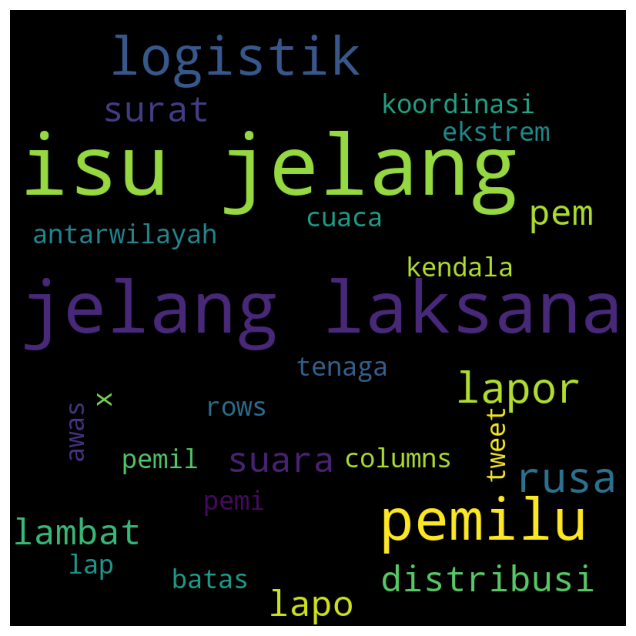

In [22]:
import os
import matplotlib.pyplot as plt
from wordcloud import WordCloud

wordcloud = WordCloud(width = 800, height = 800, background_color = 'black', max_words = 1000, min_font_size = 20).generate(str(tweet_df))
#plot the word cloud
fig = plt.figure(figsize = (8,8), facecolor = None)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()